In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import scipy.sparse.linalg as sla
import scipy.sparse as sp
from ssh_chain_single import PHOTONICChain
import graphics_template

In [2]:

def make_edge_lifting_perturbation(chain, strength=1e-6):
    """
    Diagonal perturbation: delta_i = strength * (exp(-i/xi) - exp(-(2N-1-i)/xi))
    Positive on left edge sites, negative on right edge sites.
    Lifts the degeneracy without mixing the states significantly.
    """
    n    = 2 * chain.N
    xi   = n / 4.0
    d_ph = chain.fock_photon
    d_mat = chain.fock_dim

    site_weights = np.array([np.exp(-i / xi) - np.exp(-(n - 1 - i) / xi)
                             for i in range(n)])

    # fock_states is now a flat ndarray (fock_dim, 2N)
    diag_mat  = chain.fock_states @ site_weights   # (fock_dim,)
    full_diag = strength * np.tile(diag_mat, d_ph)
    return sp.diags(full_diag, format='csr')


gap_threshold = 1e-4

def resolve_edge_states(chain, scale):
    H_pert = scale * (chain.H + make_edge_lifting_perturbation(chain, strength=1e-6))

    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(H_pert, k=6, sigma=scale * sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies_scaled   = np.array(sorted(results.keys()))
    all_energies_physical = all_energies_scaled / scale
    all_states            = np.column_stack([results[e] for e in all_energies_scaled])

    near_mask = np.abs(all_energies_physical - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_energies_physical), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies_physical - 1.0))[:2]] = True

    V_near = all_states[:, near_mask]
    E_near = all_energies_physical[near_mask]

    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(E_near - 1.0))[:2]
        V_near = V_near[:, best2]
        E_near = E_near[best2]

    e_order  = np.argsort(E_near)
    V_sorted = V_near[:, e_order]

    return V_sorted[:, 0], V_sorted[:, 1]

In [3]:
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N                = 6
gamma_zero       = 0.05
fock_photon      = 8
Omega_J          = 1.0
Chi_J            = 0.0
base_excitations = 1
k_states         = (4 * N - 1)
Omega_C   = 0.2
Chi_C_values     = np.linspace(-0.75, 0.75, 20)

In [6]:
# ------------------------------------------------------------------ #
# Compute spectra + IPR
# ------------------------------------------------------------------ #
energies_nosw, iprs_nosw = [], []
energies_sw,   iprs_sw   = [], []

for Chi_C in Chi_C_values:
    print(Chi_C)
    aux     = 0.5 * Omega_C
    gamma   = gamma_zero
    omega_r = 1.03 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
    scale   = np.exp(10 * np.abs(Chi_C))

    chain = PHOTONICChain(N, Omega_C, Chi_C, omega_r, gamma, fock_photon,
                          Omega_J, Chi_J, True)
    chain.matter_hamiltonians(n_excitations=base_excitations)

    # ── no SW ────────────────────────────────────────────────────────
    chain.build_full_hamiltonian(sw=False)
    vals, vecs = chain.get_low_lying_spectrum(k=k_states)
    idx_sort   = np.argsort(vals);  vals = vals[idx_sort];  vecs = vecs[:, idx_sort]
    try:
        evec_left, evec_right  = resolve_edge_states(chain, scale)
        vecs[:, N - 1] = evec_left;  vecs[:, N] = evec_right
    except Exception:
        pass
    chain.build_squeezed_vacuum(truncation=1)
    chain.warm_old_basis_cache()
    energies_nosw.append(vals)
    iprs_nosw.append(chain.compute_ipr_batch(vecs))

    # ── with SW ──────────────────────────────────────────────────────
    chain.build_full_hamiltonian(sw=True)
    vals, vecs = chain.get_low_lying_spectrum(k=k_states)
    idx_sort   = np.argsort(vals);  vals = vals[idx_sort];  vecs = vecs[:, idx_sort]
    try:
        evec_left, evec_right  = resolve_edge_states(chain, scale)
        vecs[:, N - 1] = evec_left;  vecs[:, N] = evec_right
    except Exception:
        pass
    chain.build_squeezed_vacuum(truncation=1)
    chain.warm_old_basis_cache()
    energies_sw.append(vals)
    iprs_sw.append(chain.compute_ipr_batch(vecs))

energies_nosw = np.array(energies_nosw)   # (n_Chi, k_states)
iprs_nosw     = np.array(iprs_nosw)
energies_sw   = np.array(energies_sw)
iprs_sw       = np.array(iprs_sw)


-0.75
-0.6710526315789473
-0.5921052631578947
-0.5131578947368421
-0.4342105263157895
-0.35526315789473684
-0.27631578947368424
-0.19736842105263164
-0.11842105263157898
-0.03947368421052633
0.03947368421052633
0.11842105263157887
0.19736842105263153
0.27631578947368407
0.3552631578947367
0.4342105263157894
0.513157894736842
0.5921052631578947
0.6710526315789473
0.75


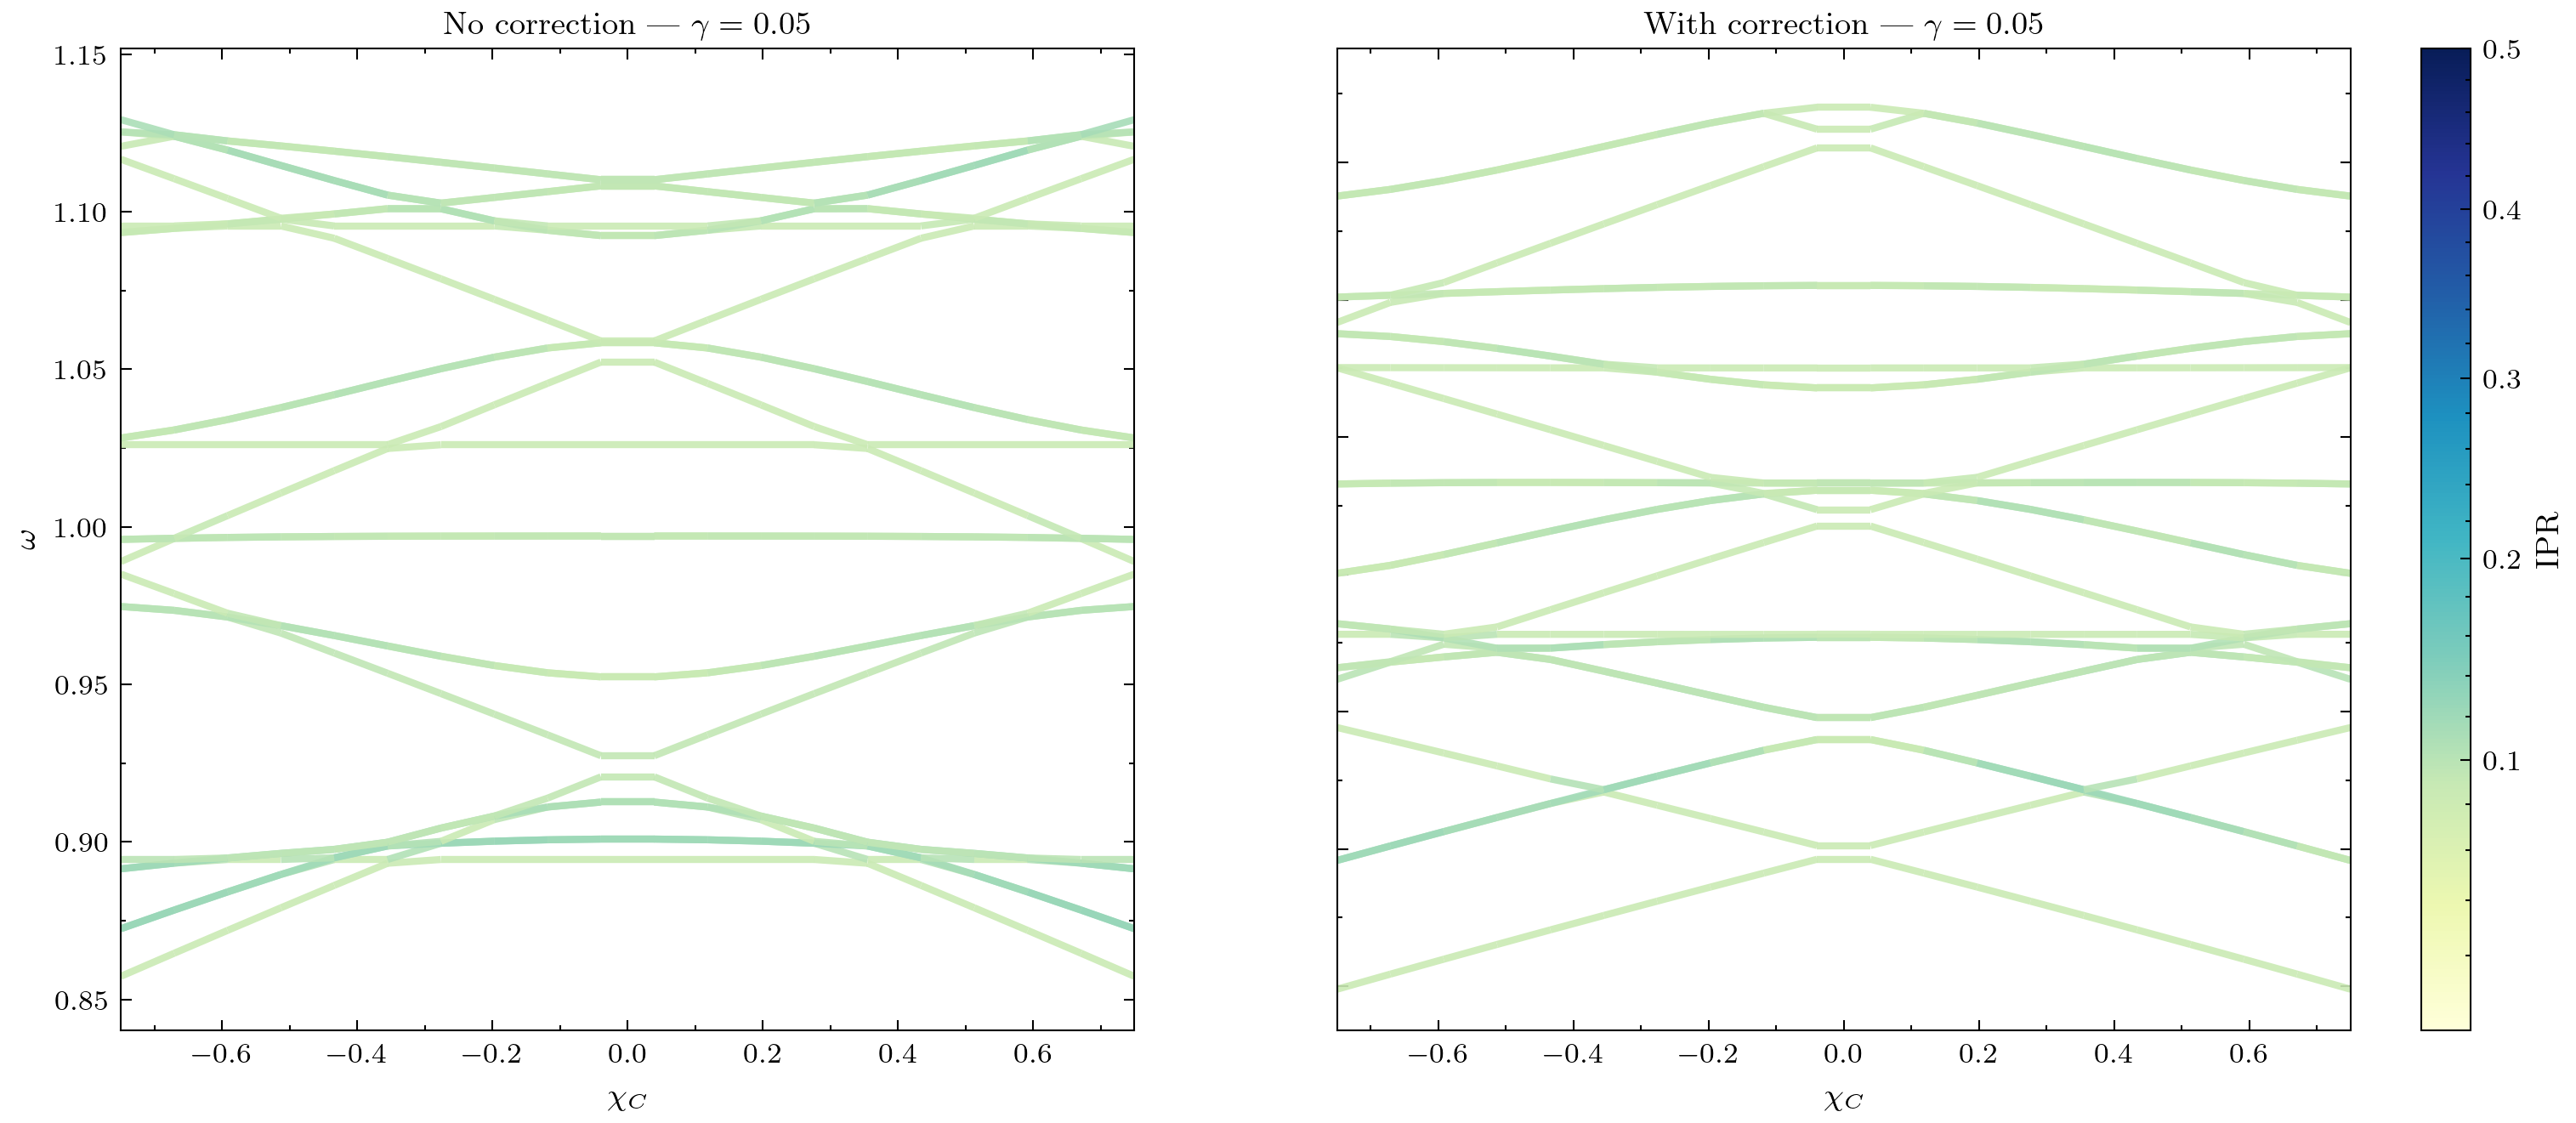

In [7]:
# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
cmap     = plt.cm.YlGnBu
ipr_min  = 1e-4
ipr_max  = 0.5
norm_ipr = mcolors.PowerNorm(gamma=0.8, vmin=ipr_min, vmax=ipr_max)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

datasets = [
    (axes[0], energies_nosw, iprs_nosw, "No correction"),
    (axes[1], energies_sw,   iprs_sw,   "With correction"),
]

for ax, energies, iprs, title in datasets:
    for band_e, band_ipr in zip(energies.T, iprs.T):
        points   = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=cmap, norm=norm_ipr,
                            linewidth=2.0, alpha=0.9)
        lc.set_array(np.clip(0.5 * (band_ipr[:-1] + band_ipr[1:]), ipr_min, None))
        ax.add_collection(lc)

    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = energies.flatten()
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.set_xlabel(r'$\chi_C$')
    ax.set_title(rf'{title} — $\gamma = {gamma_zero:.2f}$', fontsize=9, pad=4)

axes[0].set_ylabel(r'$\omega$')
axes[1].tick_params(labelleft=False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_ipr)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.03, pad=0.03)
cbar.set_label(r'IPR', fontsize=9)

# plt.tight_layout()
plt.show()

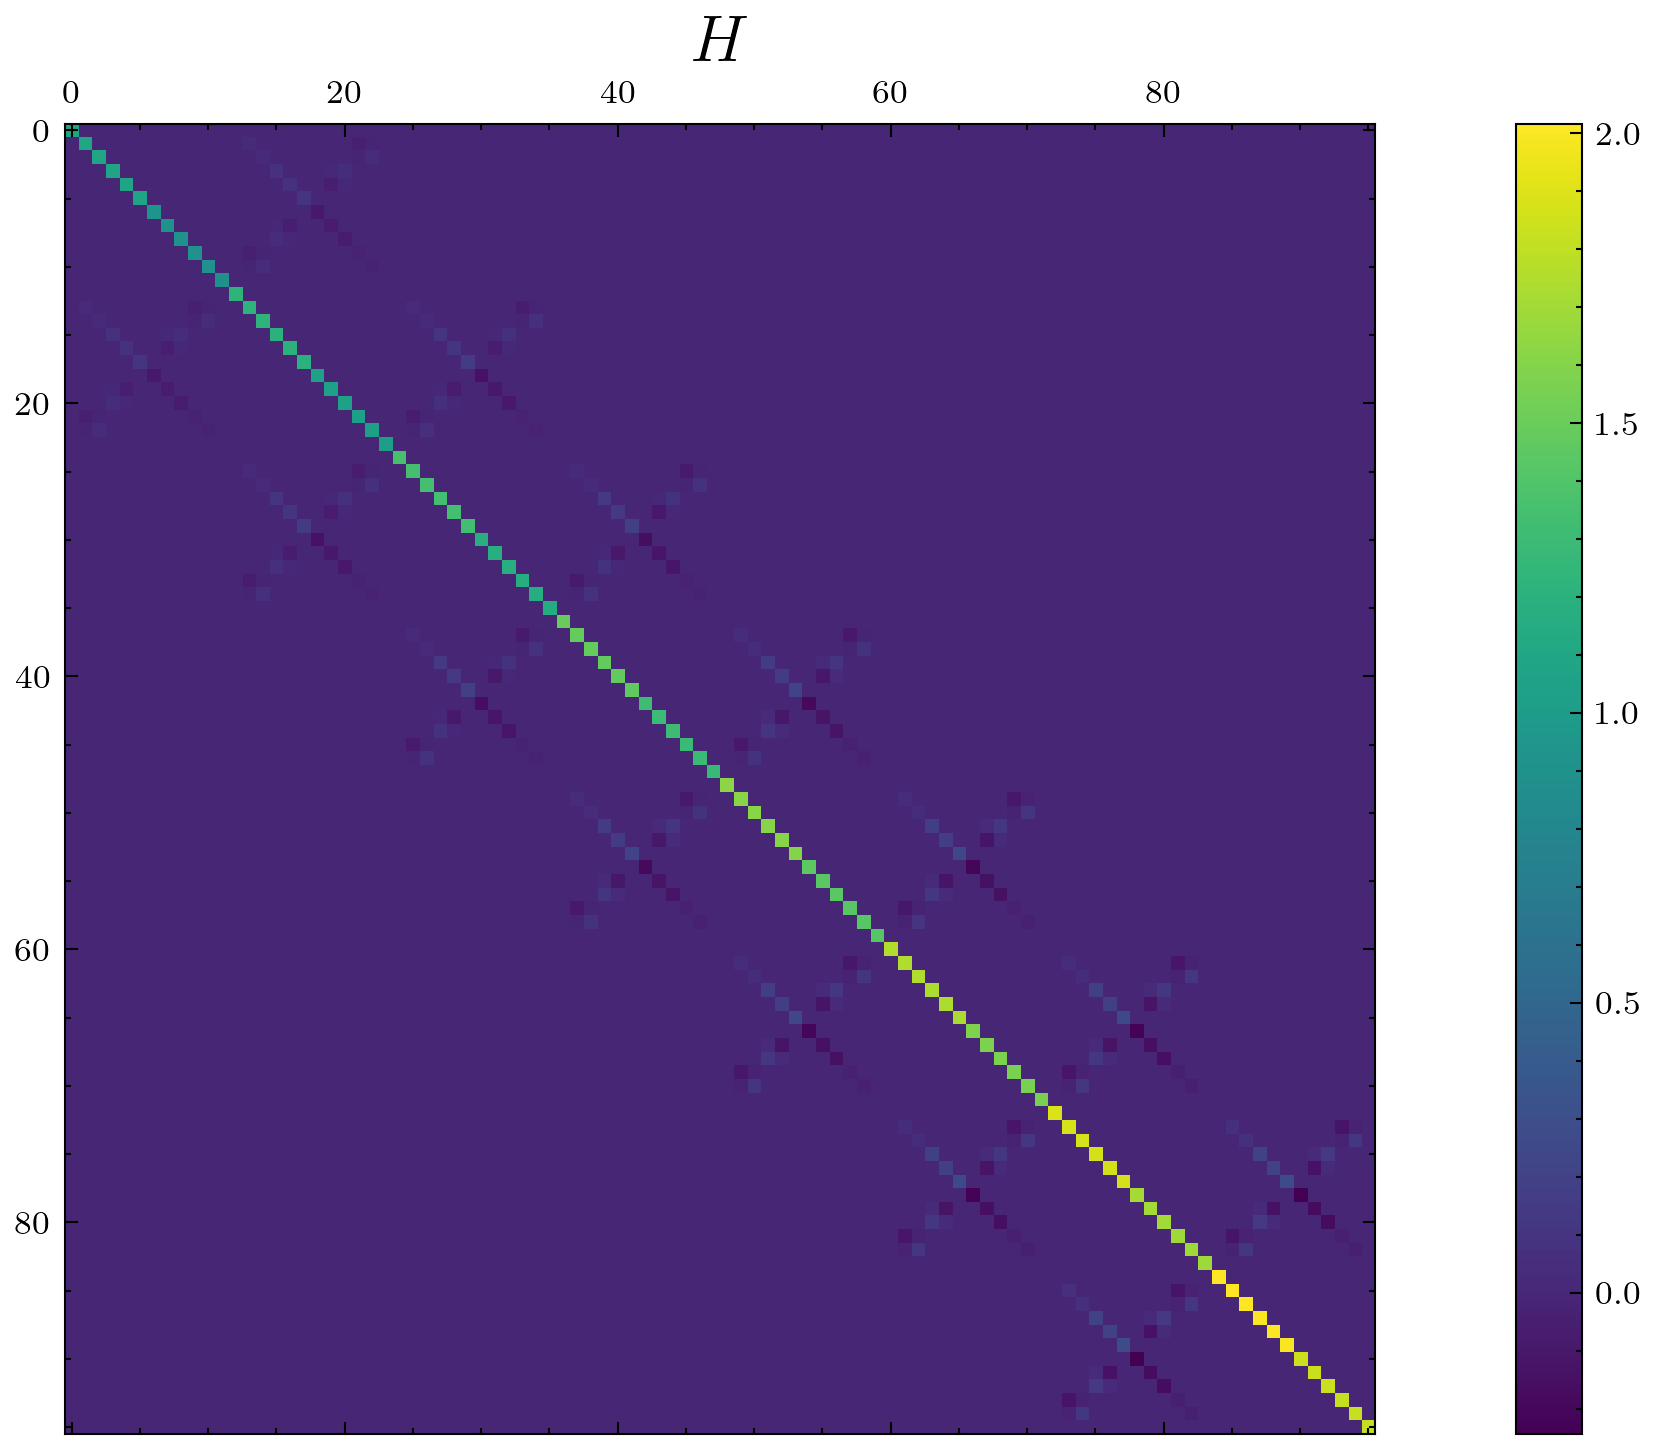

In [8]:
chain.build_full_hamiltonian()
# 1. Convert sparse matrices to dense arrays
hc_dense = np.real(chain.H.toarray())

# 2. Setup the figure with two subplots side-by-side
fig, (ax1) = plt.subplots(1, 1, figsize=(12, 5))

# --- Plot H_C_fock ---
# Since it's diagonal, we can use a standard sequential map like 'viridis'
im1 = ax1.matshow(hc_dense, cmap='viridis')
ax1.set_title("$H$", pad=15)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 3. Clean up layout and render
plt.tight_layout()
# plt.savefig('../../../figures/export/test_matrix.png', dpi = 600)
plt.show()

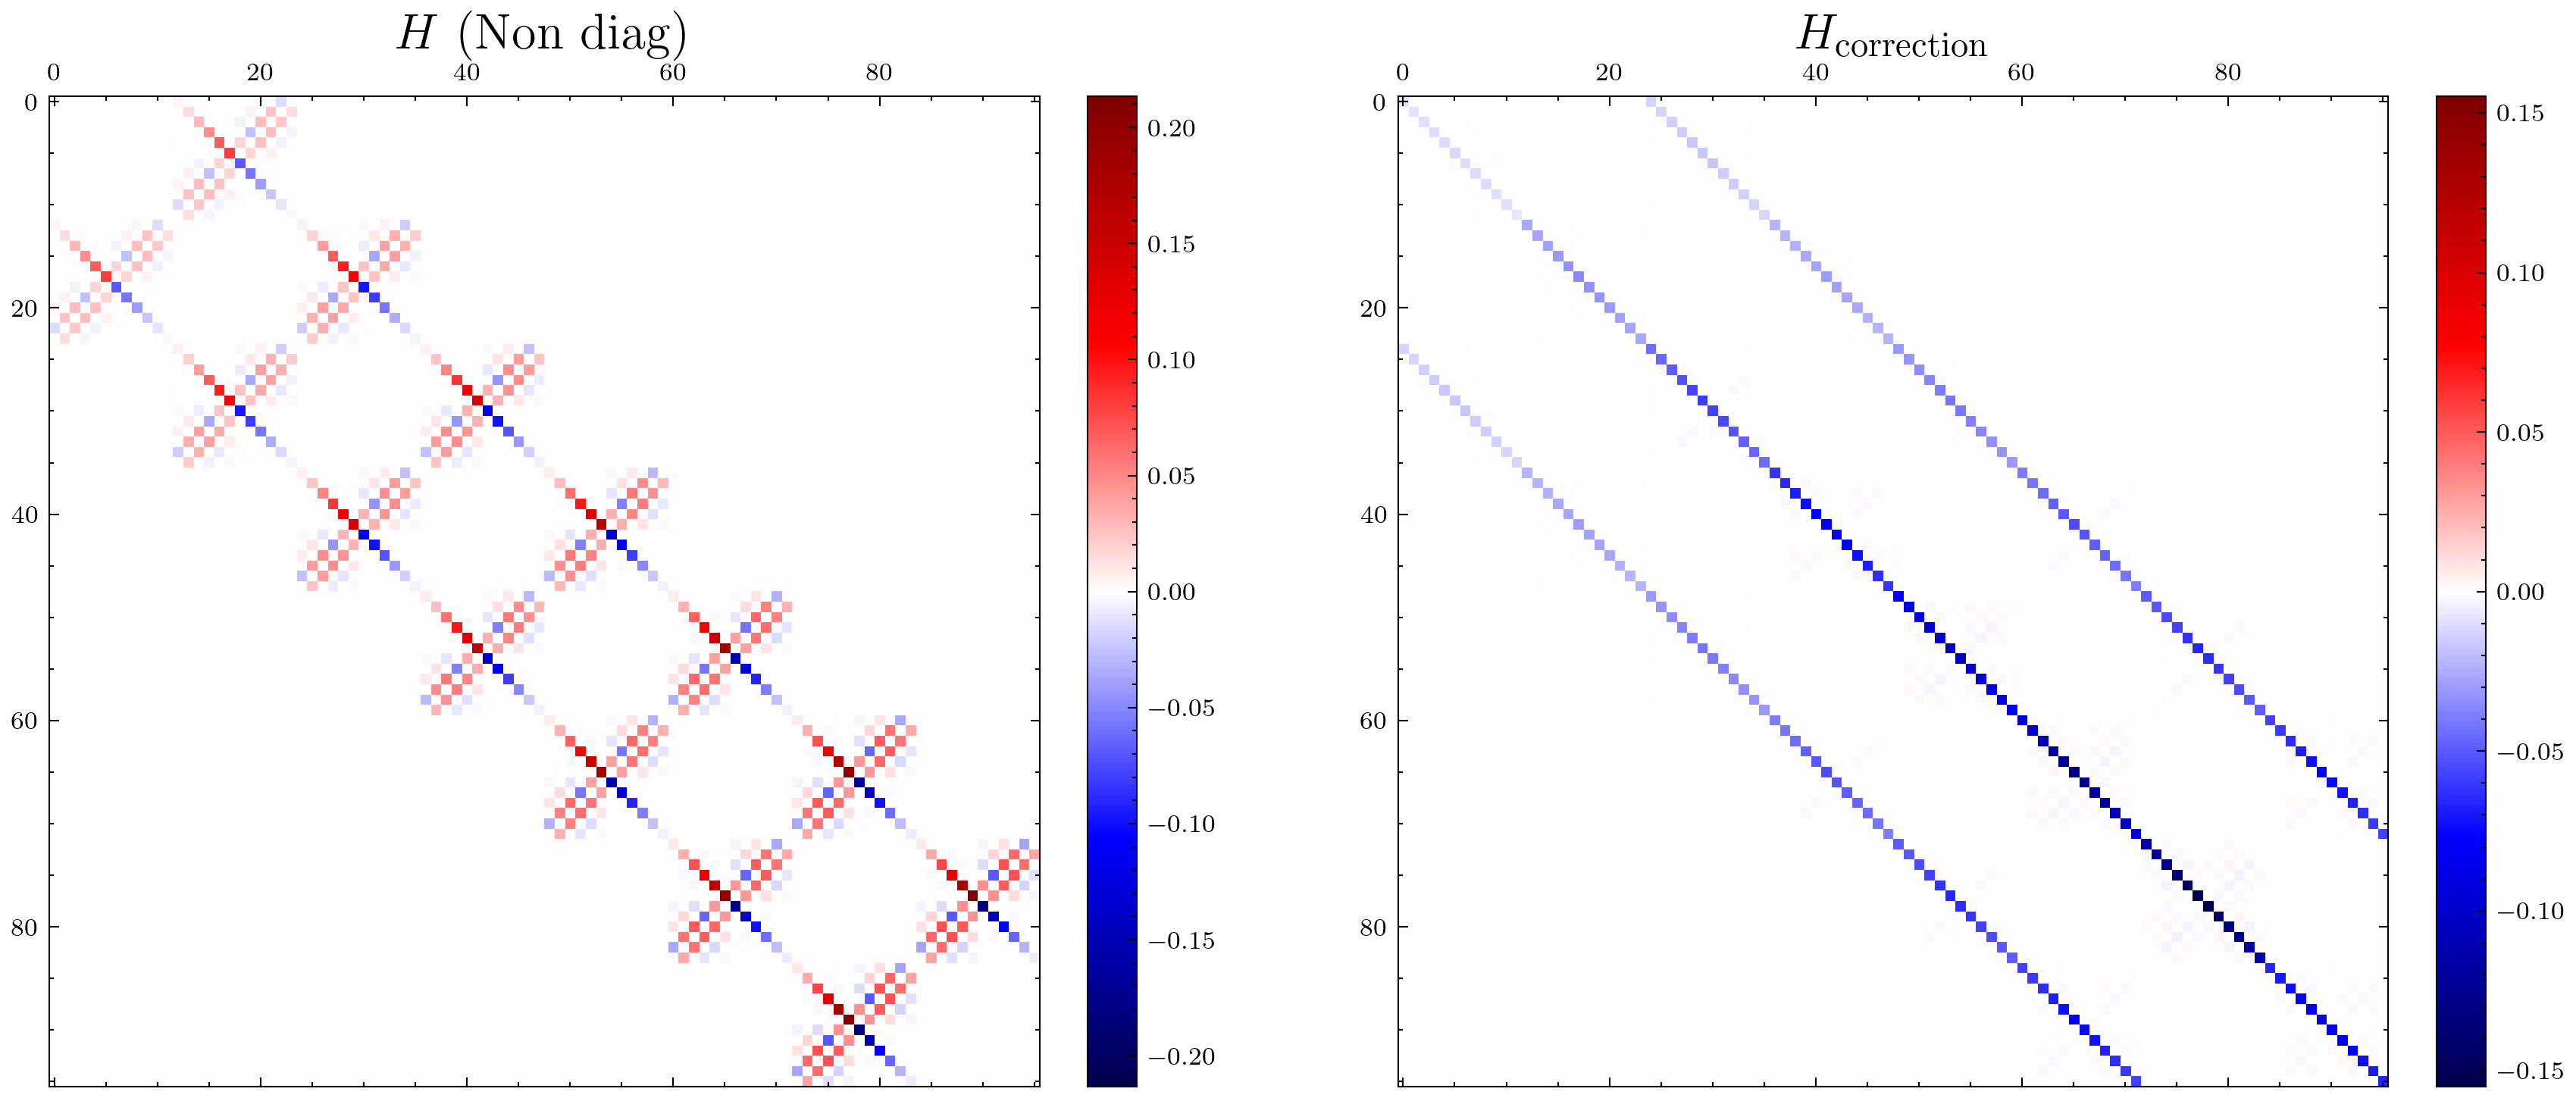

In [13]:
chain.build_full_hamiltonian()
chain.schrieffer_wolff_correction()

hc_dense = np.real(chain.H.toarray())
hc_offdiag = hc_dense - np.diag(np.diag(hc_dense))  # zero out diagonal

abs_max_c = np.max(np.abs(hc_offdiag))
if abs_max_c == 0: abs_max_c = 1e-15
hj_dense = np.real(chain.H_SW.toarray())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Use seismic centered at 0 so off-diagonal structure is visible
im1 = ax1.matshow(hc_offdiag, cmap='seismic', vmin=-abs_max_c, vmax=abs_max_c)

ax1.set_title("$H$ (Non diag)", pad=15)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

abs_max_j = np.max(np.abs(hj_dense))
if abs_max_j == 0: abs_max_j = 1e-15
im2 = ax2.matshow(hj_dense, cmap='seismic', vmin=-abs_max_j, vmax=abs_max_j)
ax2.set_title(r"$H_{\text{correction}}$", pad=15)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

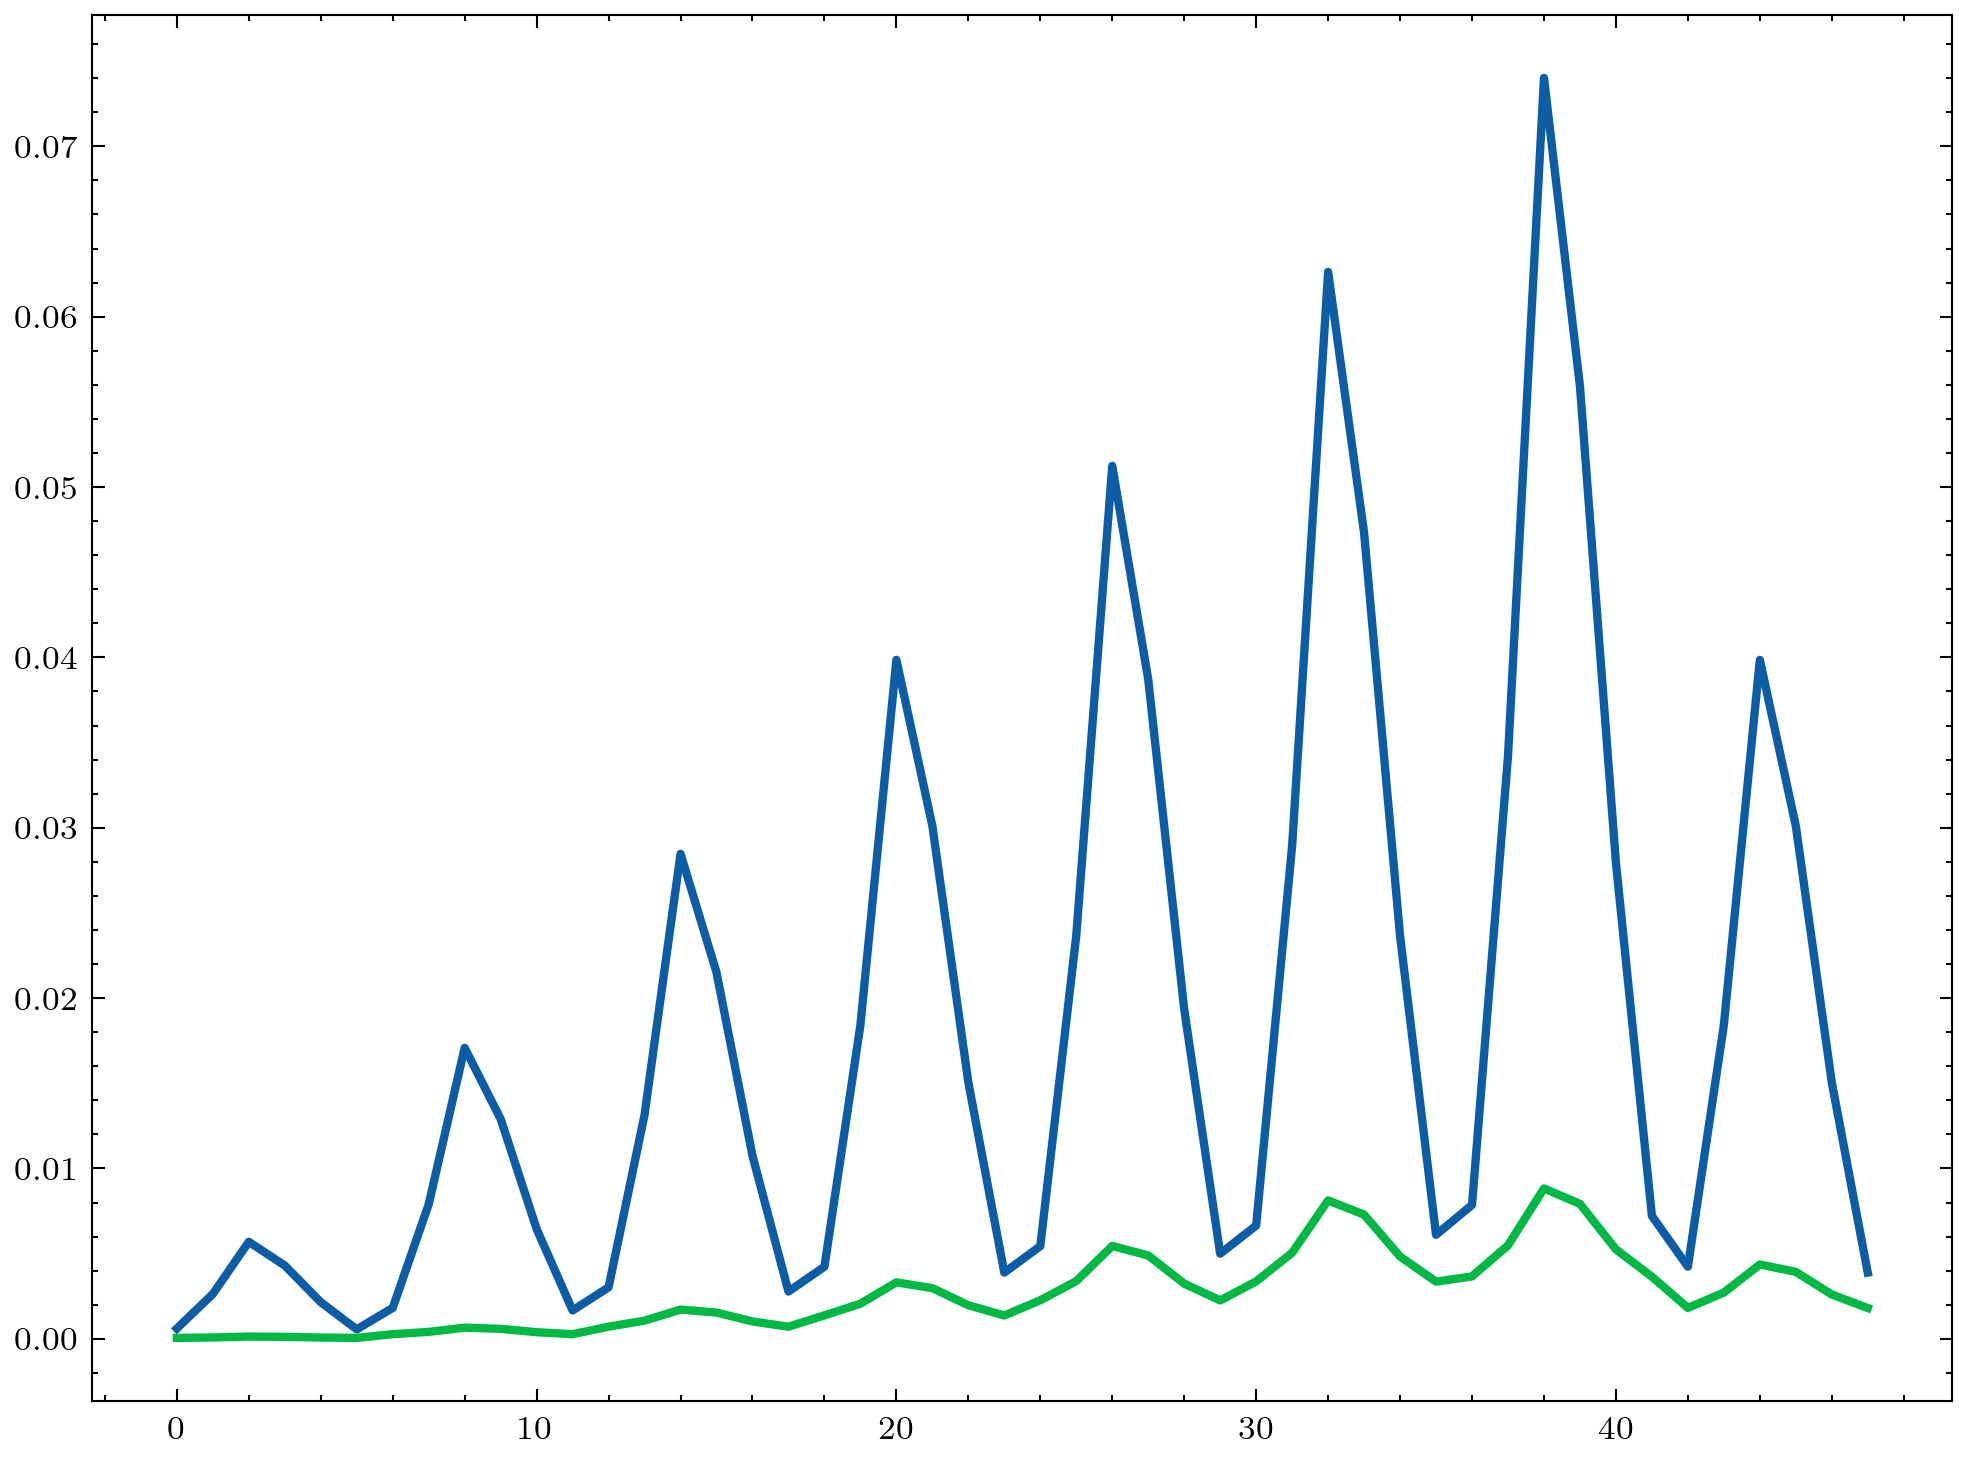

In [8]:
plt.plot(np.diag(hc_offdiag@hc_offdiag))
plt.plot(np.diag(hj_dense@hj_dense))

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from ssh_chain_single import PHOTONICChain
import graphics_template

In [60]:
N = 4
Omega_C = 0.9
Chi_C = 0.1
aux = 0.5 * Omega_C * np.sqrt(1+3*Chi_C**2)
omega_r = 1.0 * np.sqrt(1+aux) - np.sqrt(1-aux)
gamma = 0.01
fock_photon = 5
Omega_J = 1.0
Chi_J = 0.0

photonic_chain = PHOTONICChain(N, Omega_C, Chi_C, omega_r, gamma, fock_photon, Omega_J, Chi_J, PBC = False)
photonic_chain.matter_hamiltonians(n_excitations= 1)

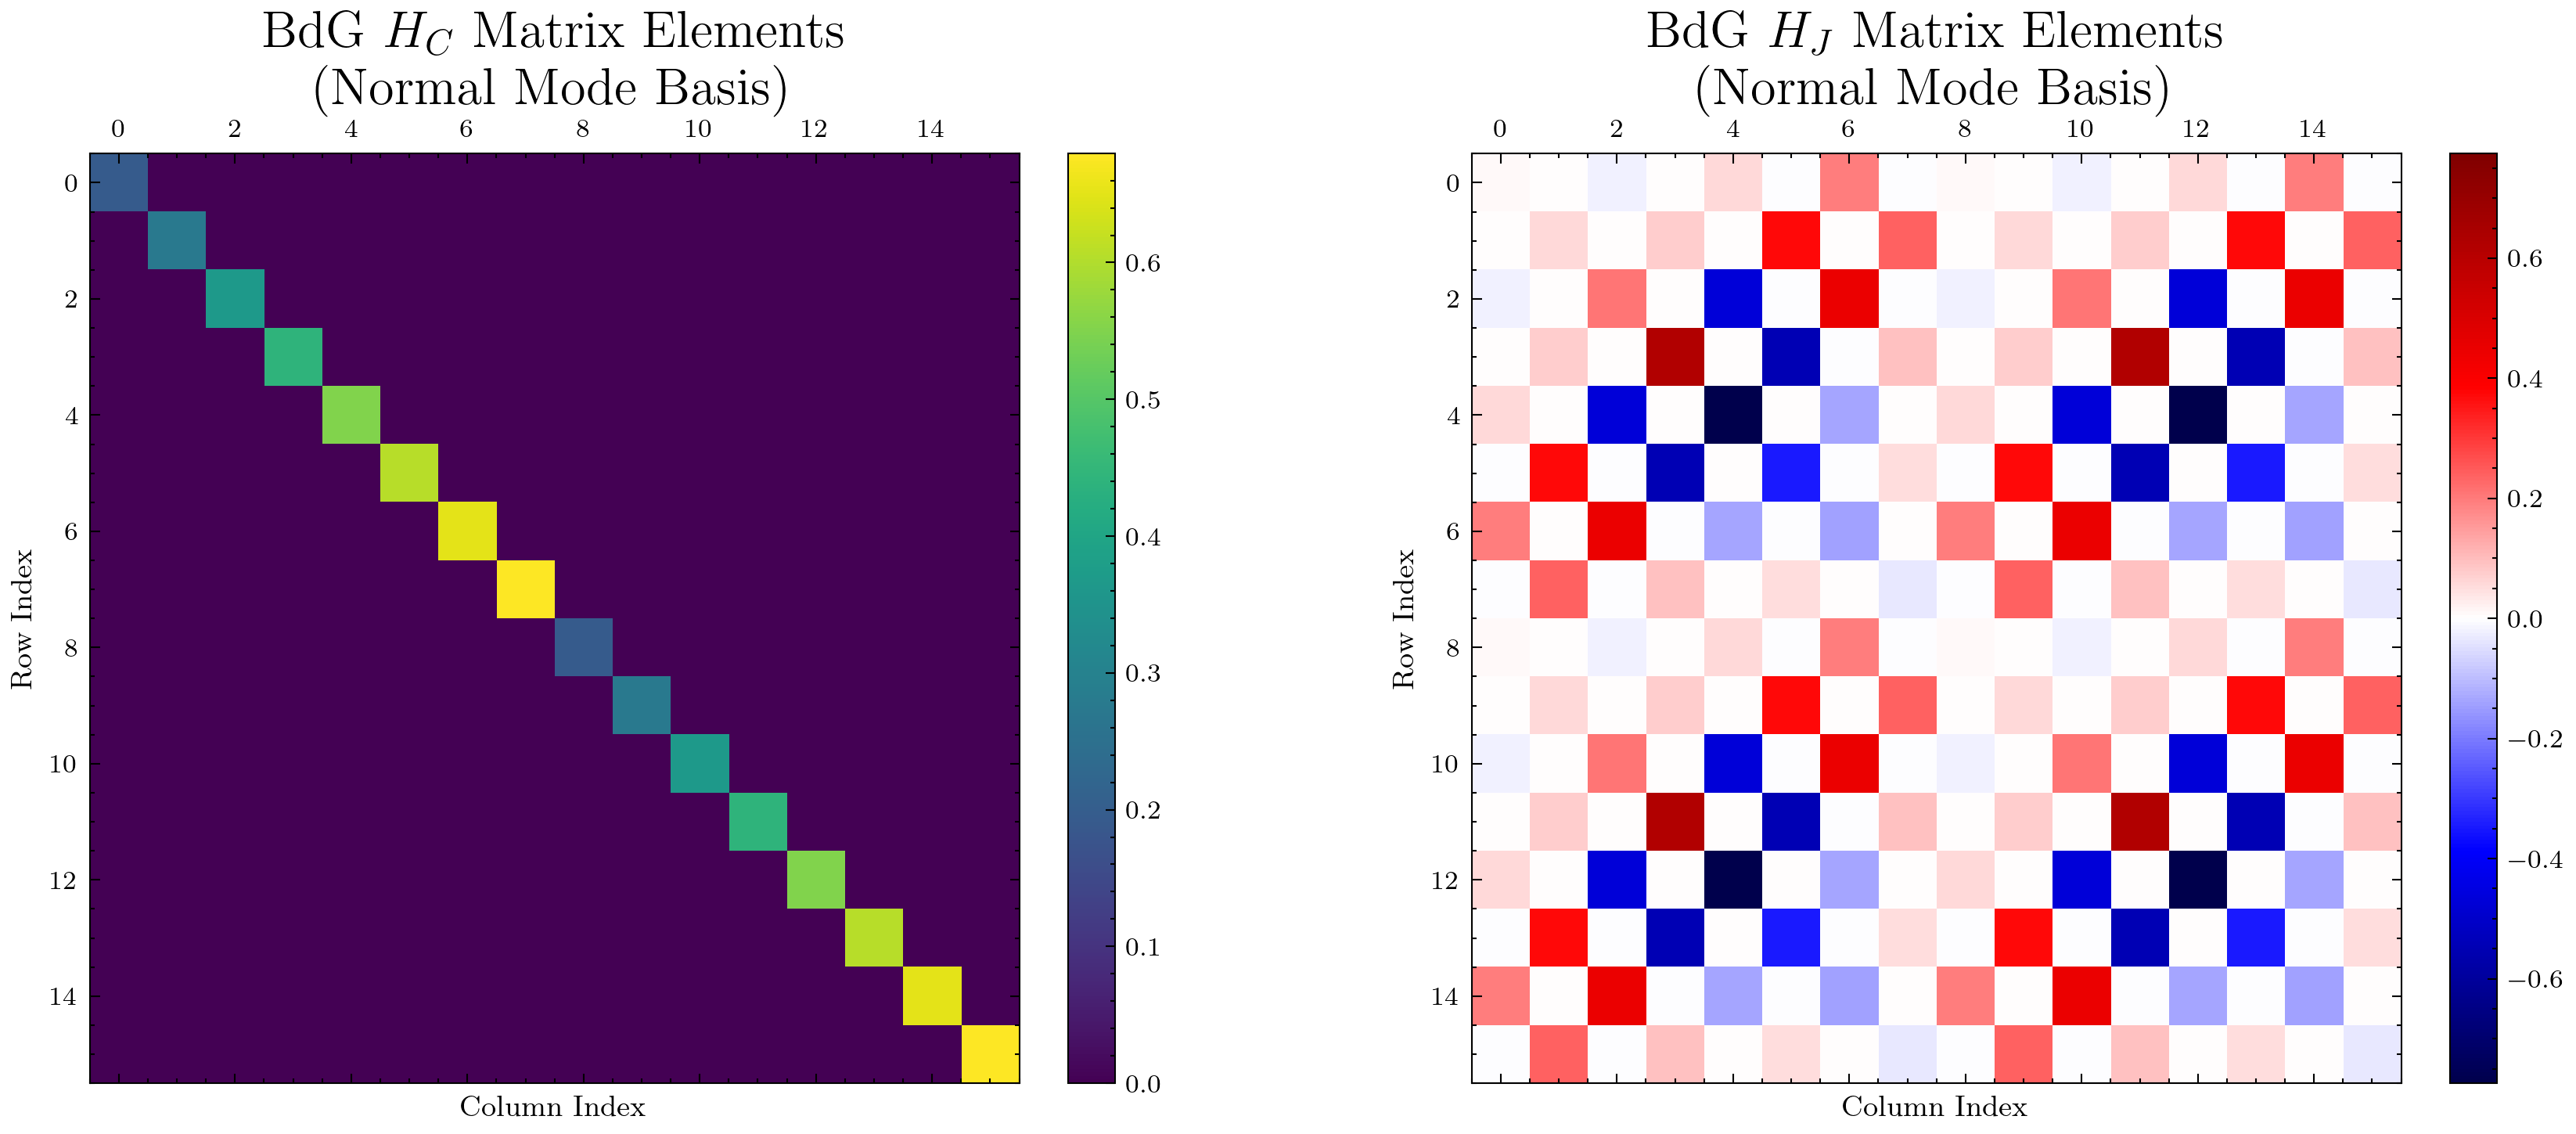

In [61]:
# ------------------------------------------------------------------ #
# 1. Instantiate the photonic_chain with some test parameters
# ------------------------------------------------------------------ #


# ------------------------------------------------------------------ #
# 2. Extract the single-particle BdG matrices from the instance
# ------------------------------------------------------------------ #
# These are the 4N x 4N matrices transformed into the normal mode basis
hc_bdg = np.real(photonic_chain.H_C)
hj_bdg = np.real(photonic_chain.H_J)

# ------------------------------------------------------------------ #
# 3. Plotting the matrix elements side-by-side
# ------------------------------------------------------------------ #
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot H_C BdG Matrix ---
# Because Van Hemmen's transformation P perfectly diagonalizes H_C_hermitian, 
# this plot will show a flawless, bright diagonal line.
abs_max_c = np.max(np.abs(hc_bdg))
im1 = ax1.matshow(hc_bdg, cmap='viridis', vmin=0, vmax=abs_max_c)
ax1.set_title("BdG $H_C$ Matrix Elements\n(Normal Mode Basis)", pad=15)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# --- Plot H_J BdG Matrix ---
# For H_J, we use a 'seismic' colormap centered at 0 to clearly view the 
# positive and negative scattering/pairing elements generated by the change of basis.
abs_max_j = np.max(np.abs(hj_bdg))
if abs_max_j == 0: abs_max_j = 1e-15  # Prevent division by zero if empty

im2 = ax2.matshow(hj_bdg, cmap='seismic', vmin=-abs_max_j, vmax=abs_max_j)
ax2.set_title("BdG $H_J$ Matrix Elements\n(Normal Mode Basis)", pad=15)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# Style grid labels to show matrix indices
for ax in [ax1, ax2]:
    ax.set_xlabel("Column Index")
    ax.set_ylabel("Row Index")
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

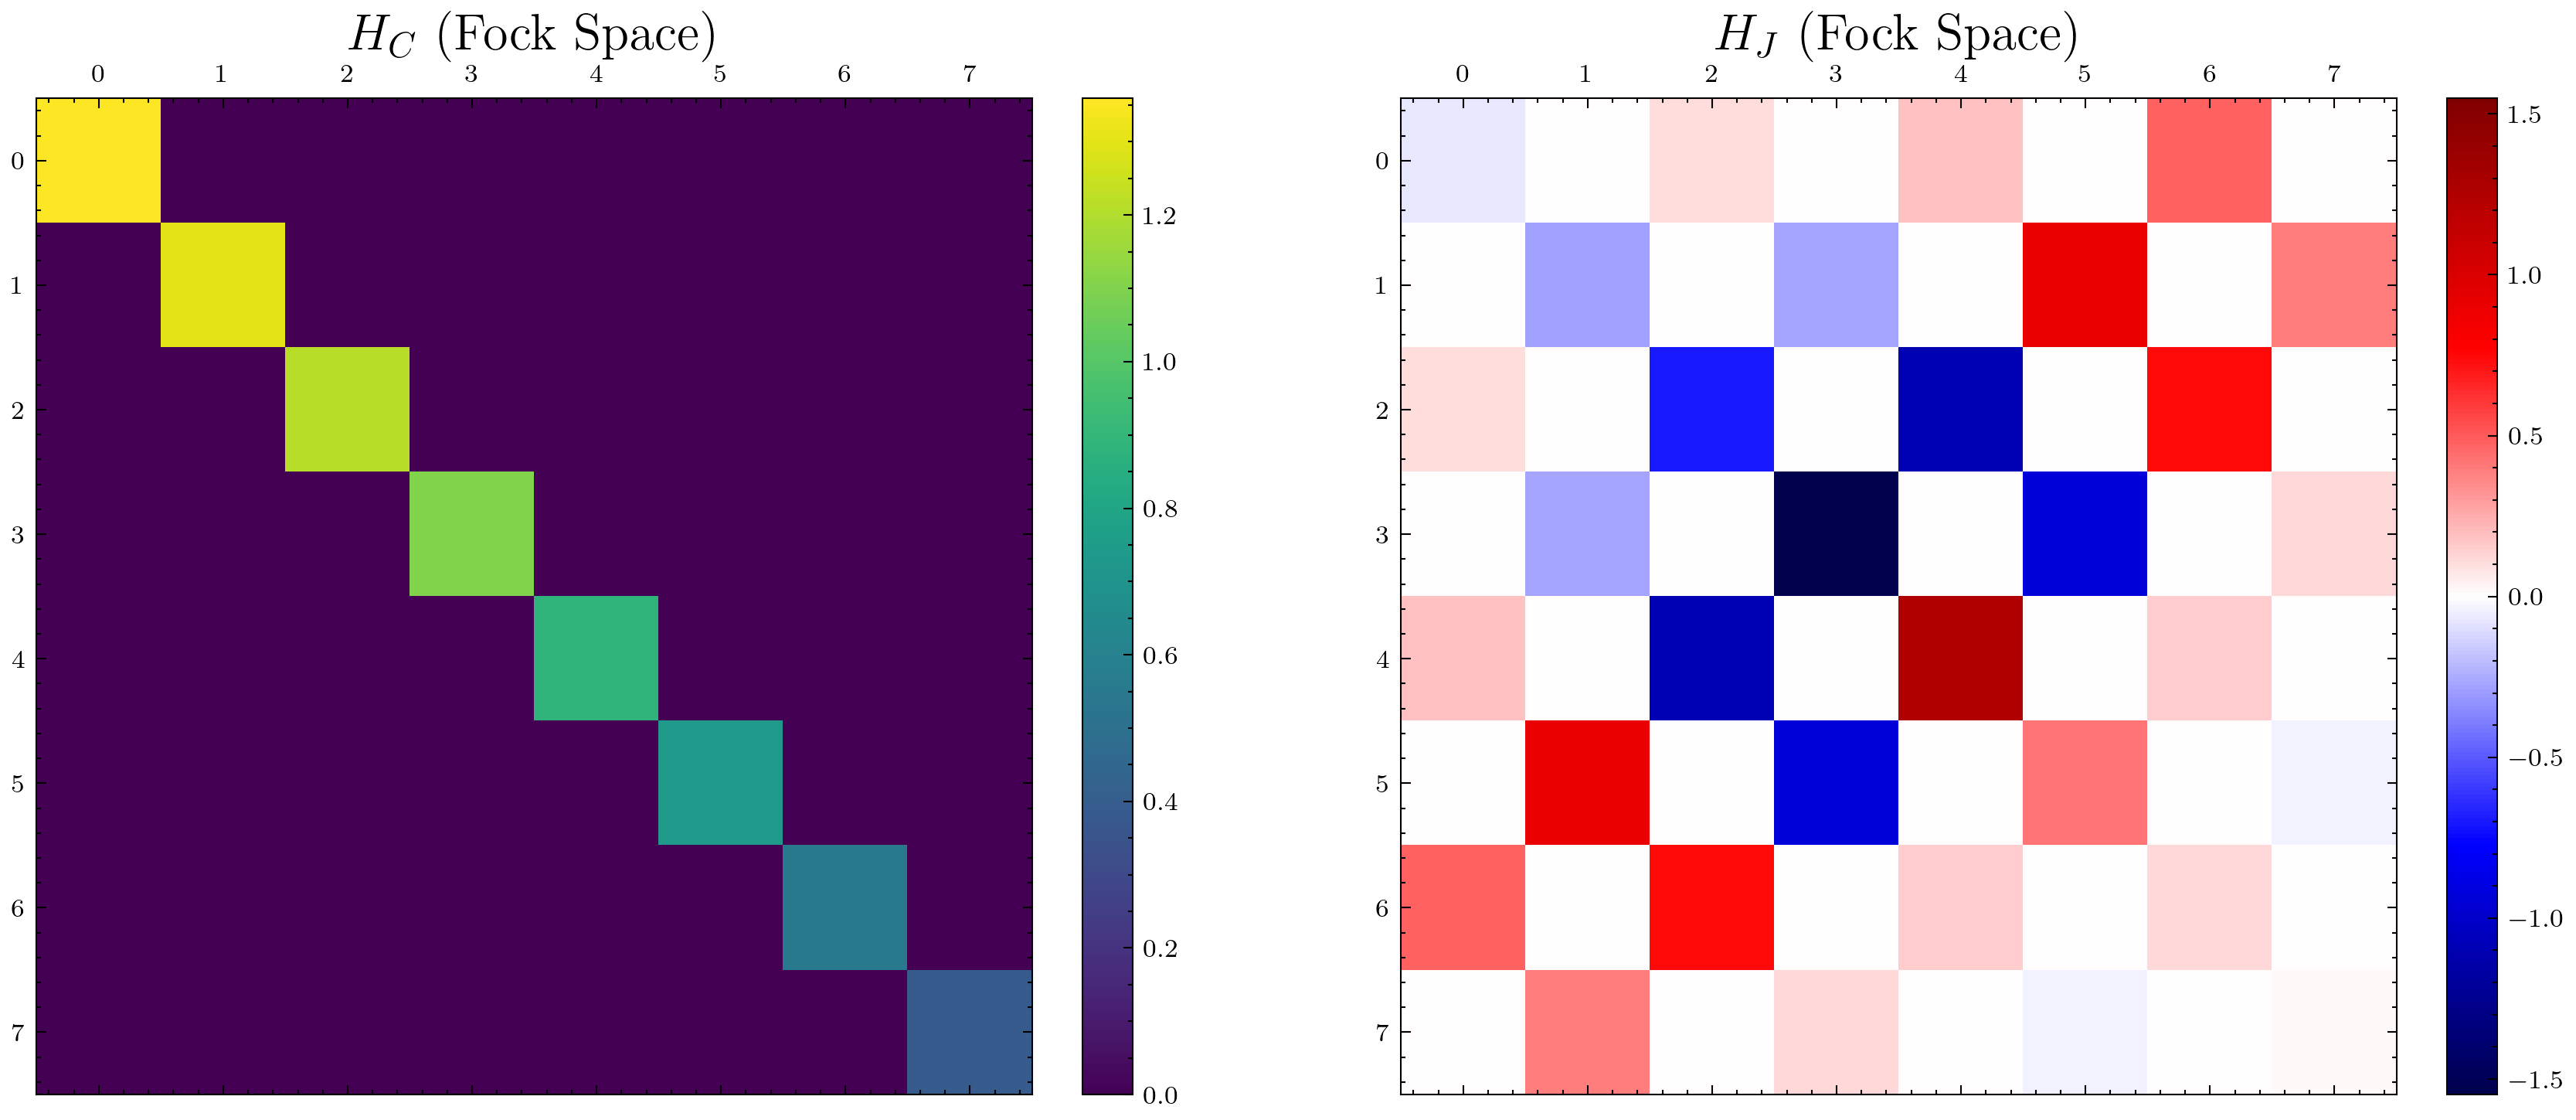

In [62]:

# 1. Convert sparse matrices to dense arrays
hc_dense = np.real(photonic_chain.H_C_fock.toarray())
hj_dense = np.real(photonic_chain.H_J_fock.toarray())

# 2. Setup the figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot H_C_fock ---
# Since it's diagonal, we can use a standard sequential map like 'viridis'
im1 = ax1.matshow(hc_dense, cmap='viridis')
ax1.set_title("$H_C$ (Fock Space)", pad=15)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# --- Plot H_J_fock ---
# For H_J, it's best to use 'seismic' centered at 0 to see positive/negative off-diagonals
abs_max_j = np.max(np.abs(hj_dense))
# Prevent division by zero if H_J happens to be completely empty/zero
if abs_max_j == 0: abs_max_j = 1e-15 

im2 = ax2.matshow(hj_dense, cmap='seismic', vmin=-abs_max_j, vmax=abs_max_j)
ax2.set_title("$H_J$ (Fock Space)", pad=15)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 3. Clean up layout and render
plt.tight_layout()
# plt.savefig('../../../figures/export/test_matrix.png', dpi = 600)
plt.show()

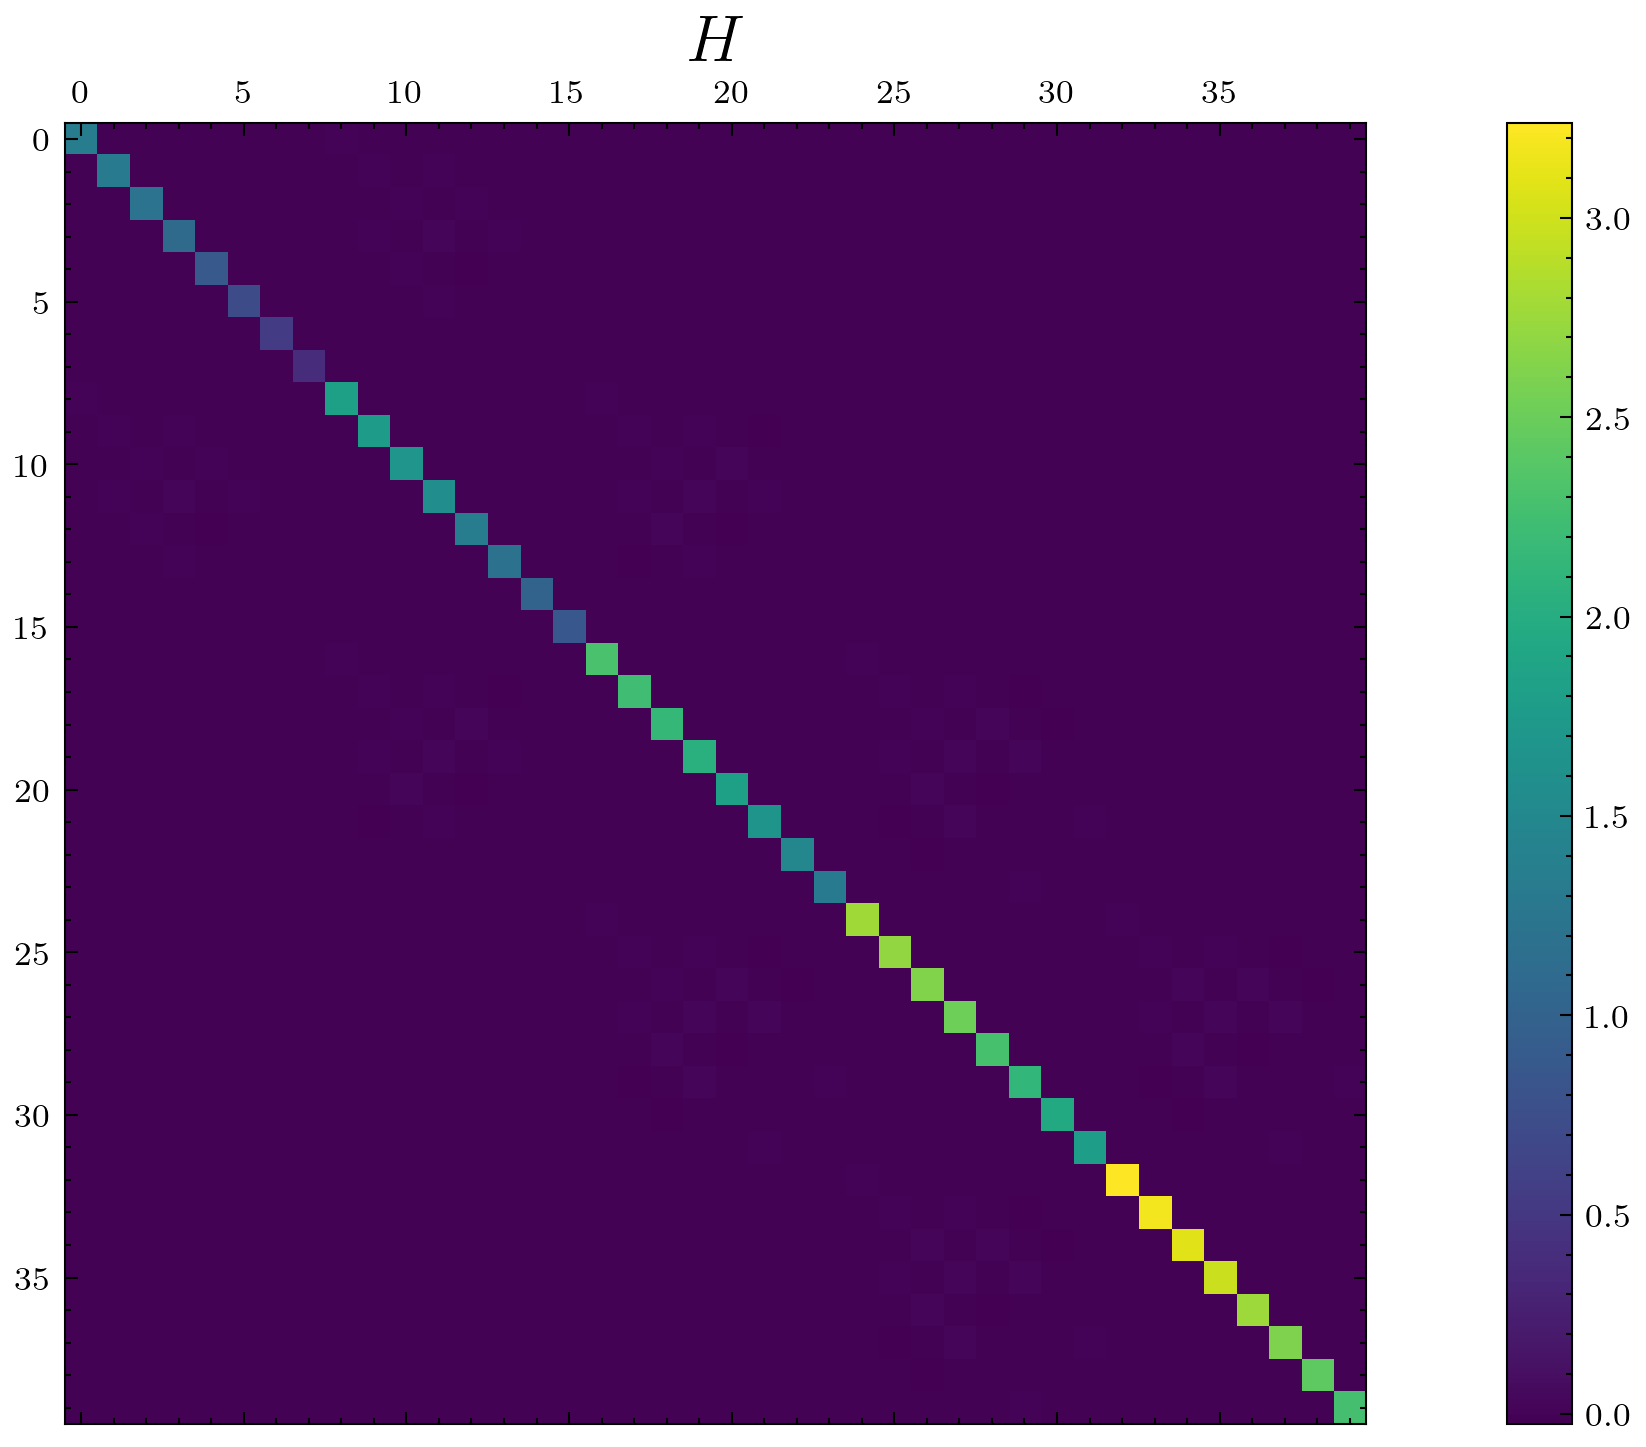

In [65]:
photonic_chain.build_full_hamiltonian()
# 1. Convert sparse matrices to dense arrays
hc_dense = np.real(photonic_chain.H.toarray())

# 2. Setup the figure with two subplots side-by-side
fig, (ax1) = plt.subplots(1, 1, figsize=(12, 5))

# --- Plot H_C_fock ---
# Since it's diagonal, we can use a standard sequential map like 'viridis'
im1 = ax1.matshow(hc_dense, cmap='viridis')
ax1.set_title("$H$", pad=15)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 3. Clean up layout and render
plt.tight_layout()
# plt.savefig('../../../figures/export/test_matrix.png', dpi = 600)
plt.show()

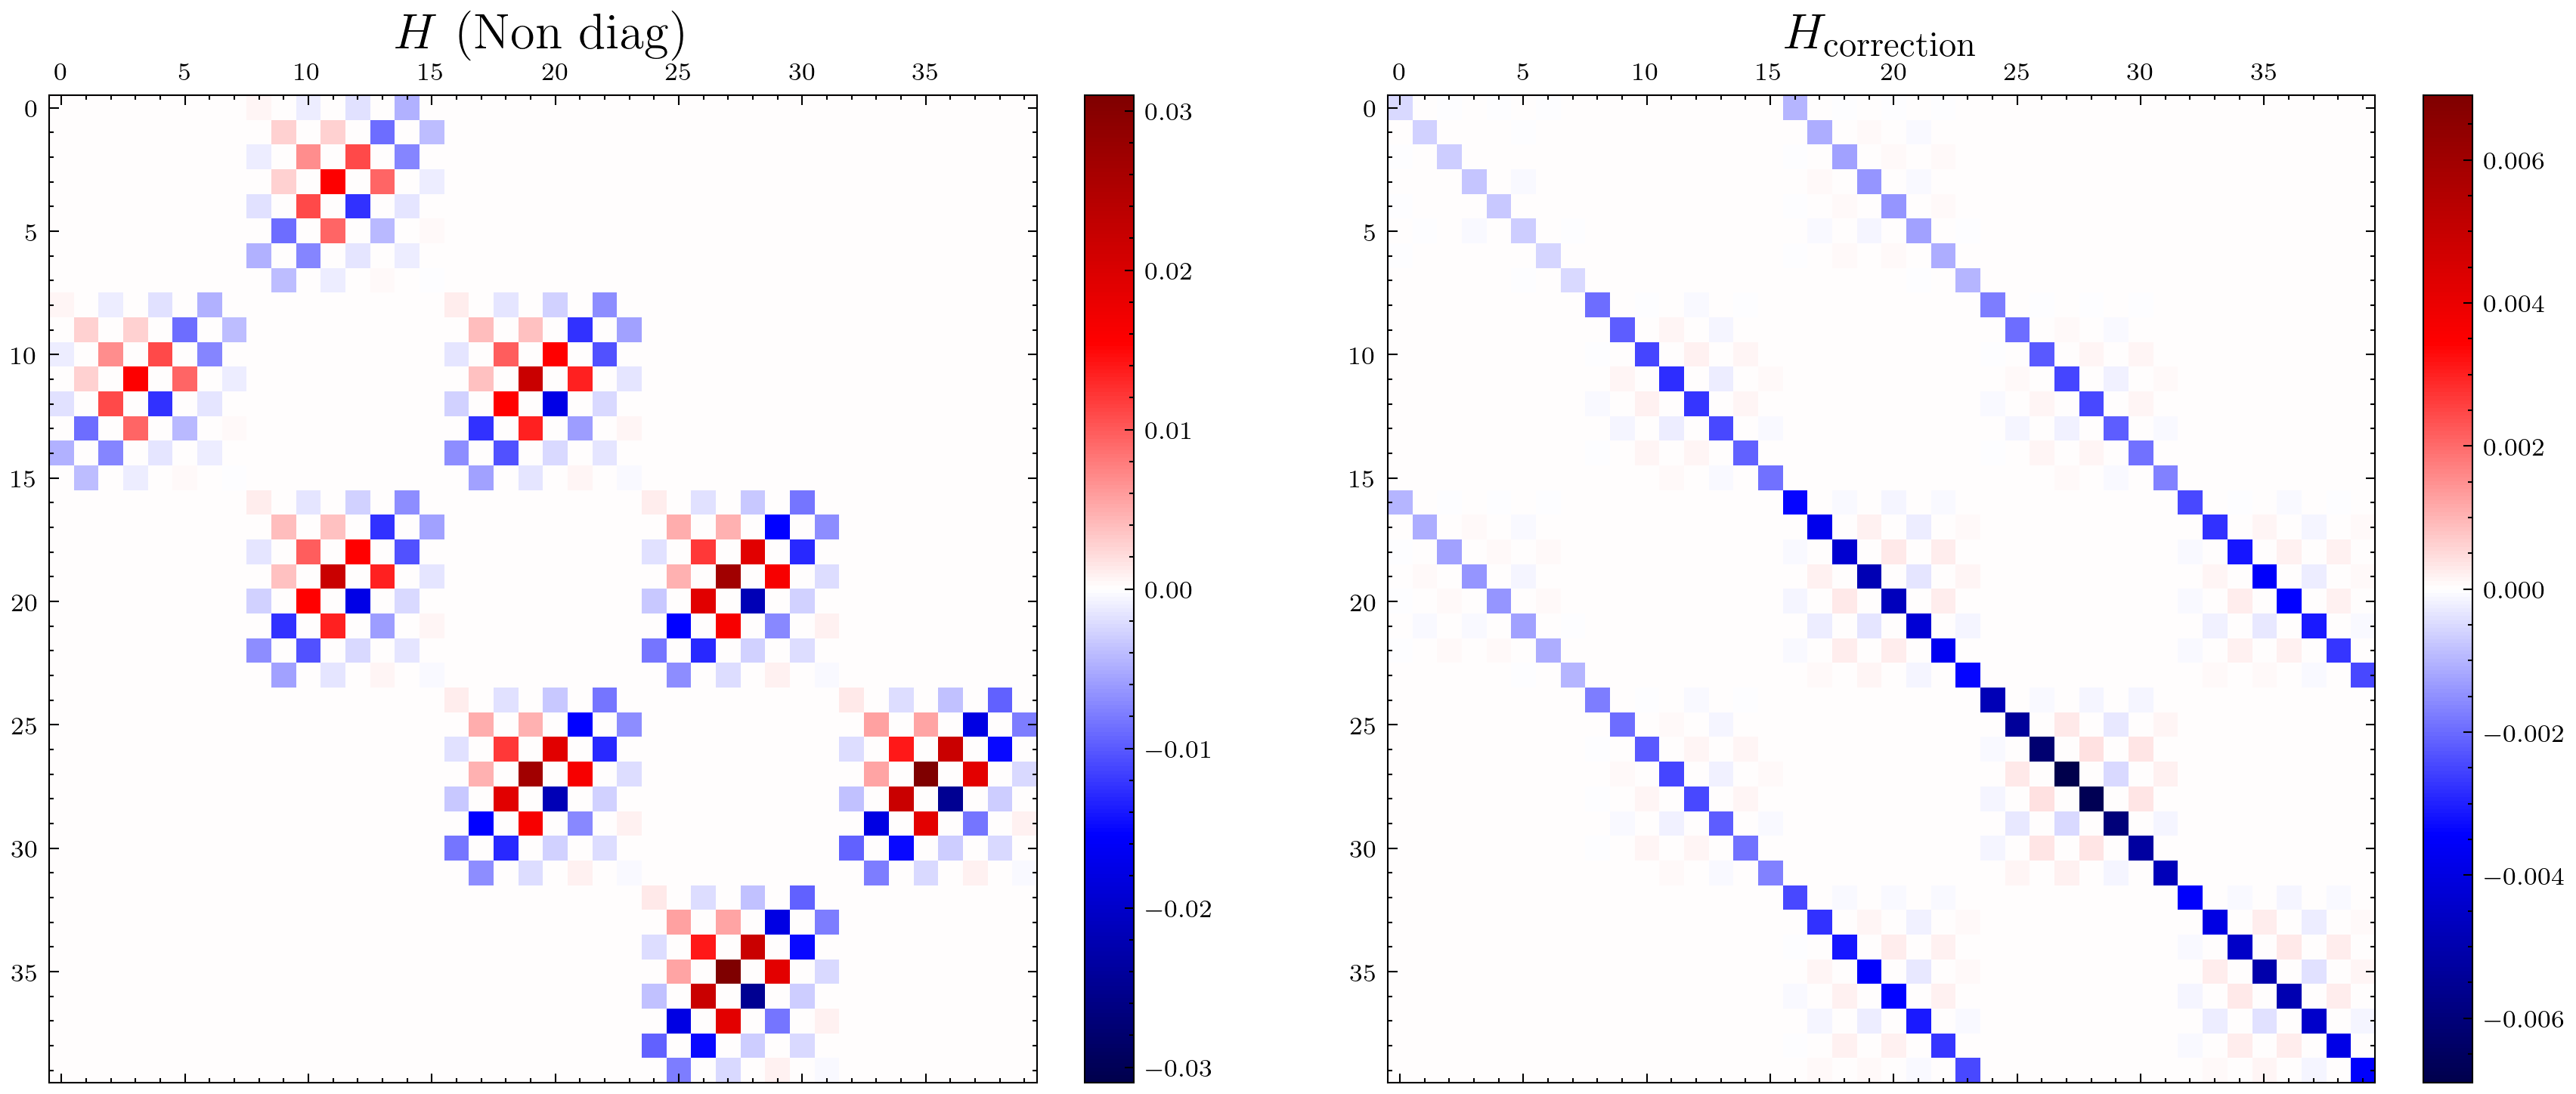

In [64]:
photonic_chain.build_full_hamiltonian()
photonic_chain.schrieffer_wolff_correction()

hc_dense = np.real(photonic_chain.H.toarray())
hc_offdiag = hc_dense - np.diag(np.diag(hc_dense))  # zero out diagonal

abs_max_c = np.max(np.abs(hc_offdiag))
if abs_max_c == 0: abs_max_c = 1e-15
hj_dense = np.real(photonic_chain.H_SW.toarray())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Use seismic centered at 0 so off-diagonal structure is visible
im1 = ax1.matshow(hc_offdiag, cmap='seismic', vmin=-abs_max_c, vmax=abs_max_c)

ax1.set_title("$H$ (Non diag)", pad=15)
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

abs_max_j = np.max(np.abs(hj_dense))
if abs_max_j == 0: abs_max_j = 1e-15
im2 = ax2.matshow(hj_dense, cmap='seismic', vmin=-abs_max_j, vmax=abs_max_j)
ax2.set_title(r"$H_{\text{correction}}$", pad=15)
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

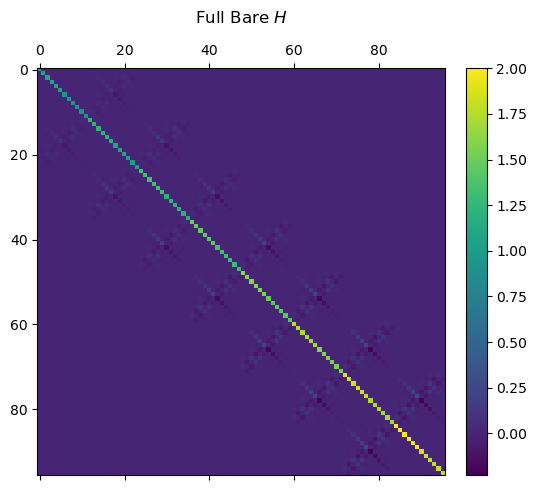

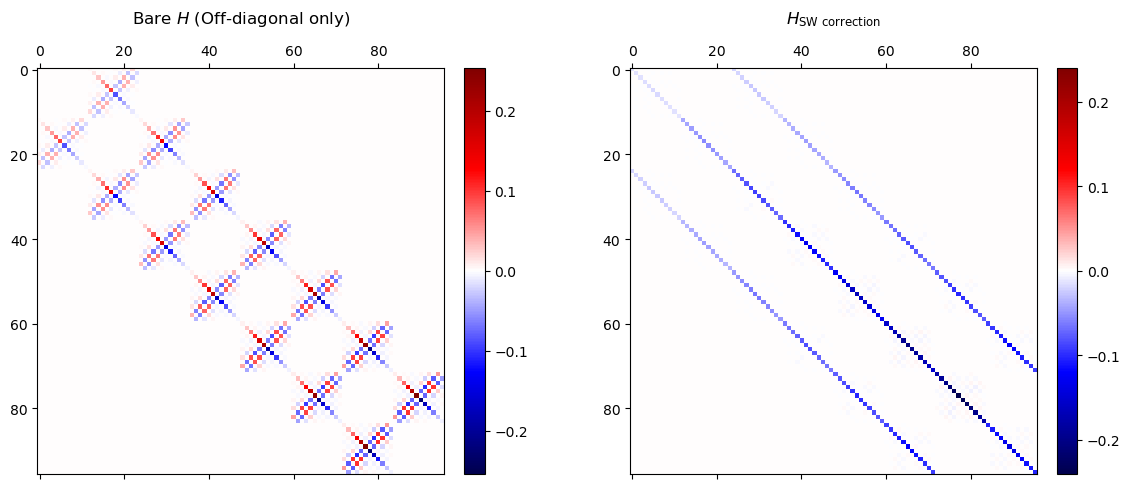

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse as sp

# Assuming you are testing the newly refactored class
from ssh_chain_sq import PHOTONICChain 

# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N                = 6
gamma_zero       = 0.05
fock_photon      = 8
Omega_J          = 1.0
Chi_J            = 0.0
base_excitations = 1
Omega_C          = 0.2

# Fix one Chi_C value for the test instead of an array
Chi_C            = 0.5 
omega_r          = 0.13 # Added missing cavity frequency parameter
PBC              = False

# ------------------------------------------------------------------ #
# 1. Initialization and Basis Setup
# ------------------------------------------------------------------ #
chain = PHOTONICChain(
    N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r, 
    gamma=gamma_zero, fock_photon=fock_photon, Omega_J=Omega_J, Chi_J=Chi_J, PBC=PBC
)

def generate_original_basis(n_modes, excitations=1):
    def compositions(n, k):
        if n == 1:
            yield (k,)
            return
        for i in range(k + 1):
            for c in compositions(n - 1, k - i):
                yield (i,) + c
                
    basis = []
    basis.extend(list(compositions(n_modes, excitations)))
    return np.array(basis)

n_modes = 2 * N
states = generate_original_basis(n_modes, excitations=base_excitations)

# Register the basis with the CompositeEngine
chain.set_basis(states)

# Build the underlying subspace matrices first
n_total = len(states)
state_index = {tuple(s): i for i, s in enumerate(states)}
chain.H_C_fock = chain.build_HC_fock(states, n_total)
chain.H_J_fock = chain.build_HJ_fock(states, state_index=state_index, n_total=n_total)

# ------------------------------------------------------------------ #
# 2. Bare Hamiltonian Plot (Full Diagonal)
# ------------------------------------------------------------------ #
# Build the full tensor product Hamiltonian without Schrieffer-Wolff yet
chain.build_full_hamiltonian(linear_coupling=True, sw=False)

hc_dense = np.real(chain.H.toarray())

fig1, ax1 = plt.subplots(1, 1, figsize=(6, 5))
im1 = ax1.matshow(hc_dense, cmap='viridis')
ax1.set_title("Full Bare $H$", pad=15)
fig1.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------ #
# 3. Off-Diagonal and Schrieffer-Wolff Correction Plots
# ------------------------------------------------------------------ #
# Calculate the SW correction (this populates chain.H_SW)
chain.schrieffer_wolff_correction()

# Isolate the off-diagonal elements of the bare Hamiltonian
hc_offdiag = hc_dense - np.diag(np.diag(hc_dense))  

abs_max_c = np.max(np.abs(hc_offdiag))
if abs_max_c == 0: abs_max_c = 1e-15

hj_dense = np.real(chain.H_SW.toarray())
abs_max_j = np.max(np.abs(hj_dense))
if abs_max_j == 0: abs_max_j = 1e-15

fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(12, 5))

# Use seismic centered at 0 so off-diagonal structure is visible
im2 = ax2.matshow(hc_offdiag, cmap='seismic', vmin=-abs_max_c, vmax=abs_max_c)
ax2.set_title("Bare $H$ (Off-diagonal only)", pad=15)
fig2.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

im3 = ax3.matshow(hj_dense, cmap='seismic', vmin=-abs_max_j, vmax=abs_max_j)
ax3.set_title(r"$H_{\text{SW correction}}$", pad=15)
fig2.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [2]:
"""
Regression test for the engine-backed ports of:
  build_squeezed_vacuum, build_unsqueezed_vacuum,
  new_to_old_fock, old_to_new_fock,
  quanta_distribution (dict branch),
  plus pass-through checks on quanta_ipr / partial_trace / decompose-compose
  round trips.
"""
import numpy as np
import warnings

from ssh_chain_single import PHOTONICChain as Orig
from ssh_chain_sq import PHOTONICChain as SQ

def dict_close(d1, d2, atol=1e-8):
    # Safely extract dictionaries if the engine returned Superposition objects
    d1_dict = d1.states if hasattr(d1, 'states') else d1
    d2_dict = d2.states if hasattr(d2, 'states') else d2
    
    keys = set(d1_dict) | set(d2_dict)
    for k in keys:
        v1 = d1_dict.get(k, 0.0)
        v2 = d2_dict.get(k, 0.0)
        if abs(v1 - v2) > atol:
            return False, k, v1, v2
    return True, None, None, None

def run(N, Omega_C, Chi_C, omega_r, gamma, fock_photon, Omega_J, Chi_J, PBC, n_exc, truncation=8):
    print(f"\n--- N={N} Chi_C={Chi_C} Chi_J={Chi_J} PBC={PBC} n_exc={n_exc} ---")
    ok = True

    # ---------------------------------------------------------
    # 1. Initialize Original Model
    # ---------------------------------------------------------
    orig = Orig(N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r, gamma=gamma,
                fock_photon=fock_photon, Omega_J=Omega_J, Chi_J=Chi_J, PBC=PBC)
    orig.matter_hamiltonians(n_excitations=n_exc)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        orig.build_squeezed_vacuum(truncation=truncation)
        orig.build_unsqueezed_vacuum(truncation=truncation)

    # ---------------------------------------------------------
    # 2. Initialize SQ Engine Model
    # ---------------------------------------------------------
    sq = SQ(N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r, gamma=gamma,
            fock_photon=fock_photon, Omega_J=Omega_J, Chi_J=Chi_J, PBC=PBC)
    sq.matter_hamiltonians(n_excitations=n_exc)
    
    # CRITICAL: Register the basis so the CompositeEngine knows the dimensions
    sq.set_basis(sq.fock_states)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        # Kept original signatures (no alpha argument!)
        sq.build_squeezed_vacuum(truncation=truncation)
        sq.build_unsqueezed_vacuum(truncation=truncation)

    # ---------------------------------------------------------
    # 3. Compare Subspace Dictionaries
    # ---------------------------------------------------------
    match, k, v1, v2 = dict_close(orig.vacuum, sq.vacuum)
    print(f"  vacuum match: {match}" + ("" if match else f"  (key={k}, orig={v1}, sq={v2})"))
    ok &= match

    match, k, v1, v2 = dict_close(orig.unsqueezed_vacuum, sq.unsqueezed_vacuum)
    print(f"  unsqueezed_vacuum match: {match}" + ("" if match else f"  (key={k}, orig={v1}, sq={v2})"))
    ok &= match

    # ---------------------------------------------------------
    # 4. Compare Transform Functions (new_to_old / old_to_new)
    # ---------------------------------------------------------
    test_states = [orig.fock_states[0], orig.fock_states[-1]]
    for ts in test_states:
        d_orig = orig.new_to_old_fock(np.array(ts, dtype=int))
        d_sq = sq.new_to_old_fock(np.array(ts, dtype=int))
        match, k, v1, v2 = dict_close(d_orig, d_sq, atol=1e-6)
        print(f"  new_to_old_fock({tuple(ts)}) match: {match}" +
              ("" if match else f"  (key={k}, orig={v1}, sq={v2})"))
        ok &= match

    old_test_state = np.zeros(2 * N, dtype=int)
    old_test_state[0] = 1
    d_orig = orig.old_to_new_fock(old_test_state)
    d_sq = sq.old_to_new_fock(old_test_state)
    match, k, v1, v2 = dict_close(d_orig, d_sq, atol=1e-6)
    print(f"  old_to_new_fock match: {match}" + ("" if match else f"  (key={k}, orig={v1}, sq={v2})"))
    ok &= match

    # ---------------------------------------------------------
    # 5. Compare Observables & Topology
    # ---------------------------------------------------------
    qd_orig = orig.quanta_distribution(orig.vacuum)
    # Extract dict if it's a Superposition
    sq_vac_dict = sq.vacuum.states if hasattr(sq.vacuum, 'states') else sq.vacuum
    qd_sq = sq.quanta_distribution(sq_vac_dict)
    match = np.allclose(qd_orig, qd_sq, atol=1e-8)
    print(f"  quanta_distribution(vacuum dict) match: {match}")
    ok &= match

    # Decompose/Compose & Partial Trace Round-Trip
    psi_orig_vac, orig_basis, _ = orig.compose_tensor_state({0: orig.vacuum})
    psi_sq_vac, _, _ = sq.compose_tensor_state({0: sq_vac_dict})
    
    # Manually compute the trace for the original model using the INFERRED dimension
    d_ph = orig.fock_photon
    d_mat_orig = len(orig_basis)
    psi_orig_reshaped = psi_orig_vac.reshape(d_ph, d_mat_orig)
    rho_orig = psi_orig_reshaped.conj().T @ psi_orig_reshaped

    # The SQ model's partial trace is already safe to call
    rho_sq = sq.partial_trace(psi_sq_vac, which_to_keep='matter')
    
    # --- NEW: Map rho_orig into the full global basis to compare with rho_sq ---
    rho_orig_full = np.zeros_like(rho_sq, dtype=complex)
    
    for i, state_i in enumerate(orig_basis):
        # Check if the state exists in the global SQ basis
        if state_i in sq.fock_state_index:
            global_i = sq.fock_state_index[state_i]
            for j, state_j in enumerate(orig_basis):
                if state_j in sq.fock_state_index:
                    global_j = sq.fock_state_index[state_j]
                    # Map the local element to the global matrix
                    rho_orig_full[global_i, global_j] = rho_orig[i, j]
                    
    match_rho = np.allclose(rho_orig_full, rho_sq, atol=1e-8)
    print(f"  partial_trace match: {match_rho}")
    ok &= match_rho

    return ok


if __name__ == "__main__":
    results = [
        run(4, 0.3, 0.5, 0.13, 0.02, 4, 1.0, 0.0, False, 2, truncation=2),
        run(3, 0.5, 0.2, 0.5, 0.01, 5, 0.3, 0.4, False, 1, truncation=2),
        run(2, 0.4, 0.0, 0.3, 0.03, 4, 0.2, 0.0, False, 2, truncation=2),
    ]
    print()
    print("ALL PASS" if all(results) else "SOME FAILED")


--- N=4 Chi_C=0.5 Chi_J=0.0 PBC=False n_exc=2 ---
  vacuum match: True
  unsqueezed_vacuum match: True
  new_to_old_fock((np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(2))) match: True
  new_to_old_fock((np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0))) match: True
  old_to_new_fock match: True
  quanta_distribution(vacuum dict) match: True
  partial_trace match: True

--- N=3 Chi_C=0.2 Chi_J=0.4 PBC=False n_exc=1 ---
  vacuum match: True
  unsqueezed_vacuum match: True
  new_to_old_fock((np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1))) match: True
  new_to_old_fock((np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0))) match: True
  old_to_new_fock match: True
  quanta_distribution(vacuum dict) match: True
  partial_trace match: True

--- N=2 Chi_C=0.0 Chi_J=0.0 PBC=False n_exc=2 ---
  vacuum match: True
  unsqueezed_vacuu

In [9]:
"""
Regression test for the tensor-backed ports.
Compares ssh_chain_sq.py against ssh_chain_single.py.
"""
import numpy as np
import warnings

from ssh_chain_single import PHOTONICChain as Orig
from ssh_chain_sq import PHOTONICChain as SQ

def dict_close(d1, d2, atol=1e-6):
    keys = set(d1) | set(d2)
    max_diff = 0
    for k in keys:
        v1 = d1.get(k, 0.0)
        v2 = d2.get(k, 0.0)
        diff = abs(v1 - v2)
        if diff > max_diff:
            max_diff = diff
    
    if max_diff > atol:
        print(f"    !!! Mismatch found! Max coefficient difference: {max_diff}")
    return max_diff <= atol

def project_dict(d, valid_index):
    """Filters a dictionary to only include states present in the active Hilbert space."""
    return {k: v for k, v in d.items() if k in valid_index}

def run(N, Omega_C, Chi_C, omega_r, gamma, fock_photon, Omega_J, Chi_J, PBC, n_exc, truncation=8):
    print(f"\n--- N={N} Chi_C={Chi_C} Chi_J={Chi_J} PBC={PBC} n_exc={n_exc} ---")
    ok = True

    # 1. Initialize Original Model
    orig = Orig(N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r, gamma=gamma,
                fock_photon=fock_photon, Omega_J=Omega_J, Chi_J=Chi_J, PBC=PBC)
    orig.matter_hamiltonians(n_excitations=n_exc)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        orig.build_squeezed_vacuum(truncation=truncation)
        orig.build_unsqueezed_vacuum(truncation=truncation)

    # 2. Initialize SQ Engine Model
    sq = SQ(N=N, Omega_C=Omega_C, Chi_C=Chi_C, omega_r=omega_r, gamma=gamma,
            fock_photon=fock_photon, Omega_J=Omega_J, Chi_J=Chi_J, PBC=PBC)
    sq.matter_hamiltonians(n_excitations=n_exc)
    sq.set_basis(sq.fock_states)

    d_ph = orig.fock_photon
    d_mat = orig.fock_dim

    # 3. Compare Vacuums (Decompose SQ vector back to dict to compare safely)
    psi_sq_vac = sq.build_squeezed_vacuum_tensor(alpha=0, truncation=truncation)
    sq_vac_dict = sq.decompose_tensor_state(psi_sq_vac).get(0, {})
    
    orig_vac_proj = project_dict(orig.vacuum, sq.fock_state_index)
    match = dict_close(orig_vac_proj, sq_vac_dict)
    print(f"  squeezed_vacuum_tensor match: {match}")
    ok &= match

    psi_sq_uvac = sq.build_unsqueezed_vacuum_tensor(alpha=0, truncation=truncation)
    sq_uvac_dict = sq.decompose_tensor_state(psi_sq_uvac).get(0, {})
    
    orig_uvac_proj = project_dict(orig.unsqueezed_vacuum, sq.fock_state_index)
    match = dict_close(orig_uvac_proj, sq_uvac_dict)
    print(f"  unsqueezed_vacuum_tensor match: {match}")
    ok &= match

    # 4. Compare Transforms
    test_state = orig.fock_states[0] 
    idx_ts = orig.fock_state_index[tuple(test_state)]
    
    # New to Old
    d_orig_nto = orig.new_to_old_fock(test_state)
    
    vec_in = np.zeros(d_ph * d_mat, dtype=complex)
    vec_in[0 * d_mat + idx_ts] = 1.0 
    psi_sq_nto = sq.transform_tensor_to_old(vec_in, truncation = truncation)
    sq_nto_dict = sq.decompose_tensor_state(psi_sq_nto).get(0, {})
    
    orig_nto_proj = project_dict(d_orig_nto, sq.fock_state_index)
    match = dict_close(orig_nto_proj, sq_nto_dict)
    print(f"  transform_tensor_to_old match: {match}")
    ok &= match

    # Old to New
    d_orig_otn = orig.old_to_new_fock(test_state)
    
    vec_in = np.zeros(d_ph * d_mat, dtype=complex)
    vec_in[0 * d_mat + idx_ts] = 1.0 
    psi_sq_otn = sq.transform_tensor_to_new(vec_in, truncation=truncation)
    sq_otn_dict = sq.decompose_tensor_state(psi_sq_otn).get(0, {})

    orig_otn_proj = project_dict(d_orig_otn, sq.fock_state_index)
    match = dict_close(orig_otn_proj, sq_otn_dict)
    print(f"  transform_tensor_to_new match: {match}")
    ok &= match

    # 5. Topology Round-Trips
    decomp_sq = sq.decompose_tensor_state(psi_sq_vac)
    psi_recomp_sq, _, _ = sq.compose_tensor_state(decomp_sq)
    match = np.allclose(psi_sq_vac, psi_recomp_sq, atol=1e-8)
    print(f"  decompose/compose round-trip match: {match}")
    ok &= match

    # Ensure we safely pass an empty dict if alpha=0 doesn't exist
    qd_orig = orig.quanta_distribution(orig_vac_proj)
    qd_sq = sq.quanta_distribution(decomp_sq.get(0, {}))
    match = np.allclose(qd_orig, qd_sq, atol=1e-8)
    print(f"  quanta_distribution (dict branch) match: {match}")
    ok &= match

    return ok

if __name__ == "__main__":
    results = [
        run(5, 0.3, 0.5, 0.13, 0.02, 4, 1.0, 0.0, False, 2, truncation=2),
        run(3, 0.5, 0.2, 0.5, 0.01, 5, 0.3, 0.4, False, 1, truncation=2),
        run(2, 0.4, 0.0, 0.3, 0.03, 4, 0.2, 0.0, False, 2, truncation=2),
    ]
    print()
    print("ALL PASS" if all(results) else "SOME FAILED")


--- N=5 Chi_C=0.5 Chi_J=0.0 PBC=False n_exc=2 ---
  squeezed_vacuum_tensor match: True
  unsqueezed_vacuum_tensor match: True
    !!! Mismatch found! Max coefficient difference: 0.027914001022837552
  transform_tensor_to_old match: False
    !!! Mismatch found! Max coefficient difference: 0.060393632404078273
  transform_tensor_to_new match: False
  decompose/compose round-trip match: True
  quanta_distribution (dict branch) match: True

--- N=3 Chi_C=0.2 Chi_J=0.4 PBC=False n_exc=1 ---
  squeezed_vacuum_tensor match: True
  unsqueezed_vacuum_tensor match: True
  transform_tensor_to_old match: True
  transform_tensor_to_new match: True
  decompose/compose round-trip match: True
  quanta_distribution (dict branch) match: True

--- N=2 Chi_C=0.0 Chi_J=0.0 PBC=False n_exc=2 ---
  squeezed_vacuum_tensor match: True
  unsqueezed_vacuum_tensor match: True
  transform_tensor_to_old match: True
  transform_tensor_to_new match: True
  decompose/compose round-trip match: True
  quanta_distribut